## Project Objective
The primary objective of this project is to create a machine learning model to forecast the chances of a telecom client leaving the company, depending on their usage of services and billing information, in addition to their demographic details.

## Phase 1: Validation and Understanding of Data

The primary aim of this phase is to understand the telecom churn data set in terms of its characteristics and validation before moving on to in-depth analysis and prediction models.


In this phase, the data set will be analyzed to understand its size, shape, data types, and other important characteristics. The data will be validated to ensure its accuracy and reliability for further analysis and modeling. Some important activities performed during this phase are:

• The process of loading and examining the data set  
• Understanding the size and shape of the data sets  
• Identifying the presence of missing values  
• Identifying duplicate values in the data sets  
• Examining statistics and data types  
• Examining the distribution of the target variable, i.e., churn  

These activities will help to improve the cleanliness of the data set for further EDA.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\abhin\Downloads\Project\Capstone projects\24CRD00163_DivyaSharma_TelecomChurnProject\data\telecom_churn.csv")
df.head()

,customer_id,gender,age,region_circle,connection_type,plan_type,contract_type,base_plan_category,tenure_months,monthly_charges,...,auto_pay_enrolled,late_payment_flag_3m,avg_payment_delay_days,arpu,segment_value,nps_score,service_rating_last_6m,received_competitor_offer_flag,retention_offer_accepted_flag,is_churn
0,100000,Female,23,West,4G,Postpaid,2 Year,Postpaid Platinum,84,1133.57,...,0,0,0.4,1133.57,High,13.0,3.2,0,0,0
1,100001,Male,72,West,4G,Prepaid,No Contract,Prepaid Unlimited,32,683.24,...,0,1,5.4,688.54,Medium,41.0,3.6,0,0,0
2,100002,Female,47,South,4G,Prepaid,No Contract,Prepaid Regular,119,307.04,...,1,0,0.0,307.05,Low,53.0,5.0,0,0,0
3,100003,Female,74,West,4G,Prepaid,No Contract,Prepaid Mini,73,213.82,...,1,0,0.0,214.89,Low,20.0,4.5,1,1,0
4,100004,Male,41,South,5G,Prepaid,No Contract,Prepaid Regular,92,383.17,...,0,0,0.5,383.99,Low,17.0,2.6,0,0,0


Loading of the dataset has been achieved.  
At first glance, it seems that each row in the dataset corresponds to a unique telecom customer, with details on their demographics, subscription plan, usage patterns, billing data, and churn status.


This step is aimed at understanding the structure of the dataset and verifying that it is suitable for further analysis and modeling.

In [2]:
df.shape

(25000, 36)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     25000 non-null  int64  
 1   gender                          25000 non-null  object 
 2   age                             25000 non-null  int64  
 3   region_circle                   25000 non-null  object 
 4   connection_type                 25000 non-null  object 
 5   plan_type                       25000 non-null  object 
 6   contract_type                   25000 non-null  object 
 7   base_plan_category              25000 non-null  object 
 8   tenure_months                   25000 non-null  int64  
 9   monthly_charges                 25000 non-null  float64
 10  total_charges                   25000 non-null  float64
 11  avg_data_gb_month               25000 non-null  float64
 12  avg_voice_mins_month            

The dataset has 25,000 rows and 36 columns, and it represents individual telecom customers. The target variable for this analysis is "is_churn," where 1 denotes a churned customer and 0 denotes an active customer.

In [4]:
df.isna().sum()

customer_id                       0
gender                            0
age                               0
region_circle                     0
connection_type                   0
plan_type                         0
contract_type                     0
base_plan_category                0
tenure_months                     0
monthly_charges                   0
total_charges                     0
avg_data_gb_month                 0
avg_voice_mins_month              0
sms_count_month                   0
overage_charges                   0
is_family_plan                    0
is_multi_service                  0
network_issues_3m                 0
dropped_call_rate                 0
avg_data_speed_mbps               0
num_complaints_3m                 0
num_complaints_12m                0
call_center_interactions_3m       0
last_complaint_resolution_days    0
app_logins_30d                    0
selfcare_transactions_30d         0
auto_pay_enrolled                 0
late_payment_flag_3m        

In [5]:
df.isna().sum().sum()

np.int64(0)

All features in the data set were subjected to a thorough missing value check.

From the results of the analysis, it is clear that there are no missing values in the data set. This ensures that there is no need for data imputation or data cleaning at this particular time, and we can progress with our analysis.

In [6]:
df.duplicated().sum()

np.int64(0)

Duplicate records were checked to ensure that each row represents a unique customer observation.

The dataset does not contain duplicate rows, confirming that the dataset is clean from duplication issues.

In [7]:
df.dtypes

customer_id                         int64
gender                             object
age                                 int64
region_circle                      object
connection_type                    object
plan_type                          object
contract_type                      object
base_plan_category                 object
tenure_months                       int64
monthly_charges                   float64
total_charges                     float64
avg_data_gb_month                 float64
avg_voice_mins_month              float64
sms_count_month                   float64
overage_charges                   float64
is_family_plan                      int64
is_multi_service                    int64
network_issues_3m                   int64
dropped_call_rate                 float64
avg_data_speed_mbps               float64
num_complaints_3m                   int64
num_complaints_12m                  int64
call_center_interactions_3m         int64
last_complaint_resolution_days    

Data types were reviewed to ensure numerical and categorical features are correctly represented. Any inconsistencies will be corrected in subsequent steps.

In [8]:
df.describe()

,customer_id,age,tenure_months,monthly_charges,total_charges,avg_data_gb_month,avg_voice_mins_month,sms_count_month,overage_charges,is_family_plan,...,selfcare_transactions_30d,auto_pay_enrolled,late_payment_flag_3m,avg_payment_delay_days,arpu,nps_score,service_rating_last_6m,received_competitor_offer_flag,retention_offer_accepted_flag,is_churn
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,112499.500000,45.960200,60.149600,475.518315,27230.695507,25.107675,602.187920,50.652920,55.209308,0.24872,...,1.993360,0.401440,0.200040,1.285748,477.978036,20.097920,3.789316,0.151400,0.100040,0.414280
std,7217.022701,16.401422,34.374772,267.550787,23717.163861,9.907997,247.929808,28.547638,43.627134,0.43228,...,1.418604,0.490199,0.400038,1.686236,267.818407,24.896257,0.672727,0.358446,0.300059,0.492607
min,100000.000000,18.000000,1.000000,99.000000,159.030000,0.500000,30.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,99.000000,-80.000000,1.000000,0.000000,0.000000,0.000000
25%,106249.750000,32.000000,31.000000,300.607500,10310.812500,18.390000,432.000000,30.000000,23.517500,0.00000,...,1.000000,0.000000,0.000000,0.200000,302.170000,3.000000,3.300000,0.000000,0.000000,0.000000
50%,112499.500000,46.000000,60.000000,385.735000,20840.650000,25.100000,603.000000,50.000000,50.790000,0.00000,...,2.000000,0.000000,0.000000,0.700000,387.870000,20.000000,3.800000,0.000000,0.000000,0.000000
75%,118749.250000,60.000000,90.000000,601.250000,36884.147500,31.820000,770.250000,70.000000,79.060000,0.00000,...,3.000000,1.000000,0.000000,1.500000,604.402500,37.000000,4.300000,0.000000,0.000000,1.000000
max,124999.000000,74.000000,119.000000,1603.490000,177878.030000,71.800000,1848.000000,173.000000,451.590000,1.00000,...,9.000000,1.000000,1.000000,11.000000,1603.490000,100.000000,5.000000,1.000000,1.000000,1.000000


Basic sanity checks were performed to identify logically incorrect values such as negative tenure or unrealistic customer age. No major violations were observed at this stage.

In [9]:
churn_rate = df["is_churn"].value_counts(normalize=True)*100
churn_rate

is_churn
0    58.572
1    41.428
Name: proportion, dtype: float64

## Phase 1 Summary
The data was examined extensively in this phase to determine the quality of the data and to understand the data.
The data set has 25,000 client entries, and there are 36 attributes in the data set, which cover service usage, subscription options, client demographics, and invoice details.
The key findings of this phase are:                                                                                                     
• There are no missing entries in the data set.  
                                                                    • There were no duplicate entries in the data set.                                                                                                   
• The data types seem to match the characteristics of the data.  
• According to the churn distribution, almost 41% of the clients have left.  
These results confirm the quality of the data and its suitability for further investigation.  
For the identification of trends, relationships, and possible reasons for customer churn, exploratory data analysis will be performed in the next phase.

## Phase 2: Exploratory Data Analysis (EDA)

The objective of the second phase of the project is to analyze the telecom churn data set to reveal trends, patterns, and relationships that exist among different variables in the data set in relation to customer churn.

The ease of understanding the different factors that influence customer churn, such as the demographic factors of the customers, the plans that the customers have subscribed to, the usage patterns of the customers, as well as the billing patterns of the customers, is greatly aided by the EDA technique.

In the entire phase of the project, the following will be achieved:

* Analyze the distribution of the different variables in the data set  
* Analyze the relationship that exists between different variables in the data set and customer churn  
* To gain deeper insight into the behavior of the customers, the EDA technique will be employed through the use of visual aids  

The next phase of the project will be achieved by the insights gained in the EDA technique.

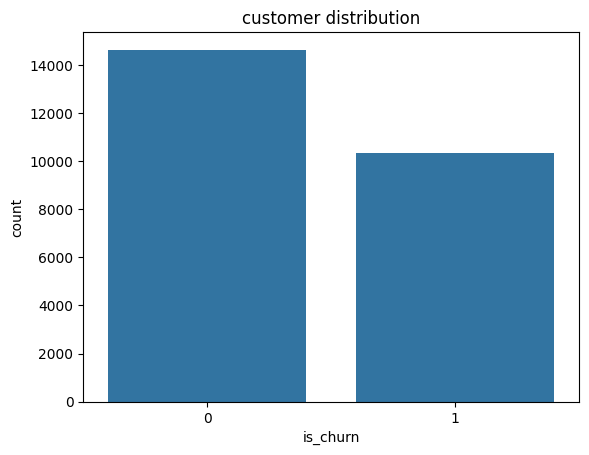

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="is_churn", data = df)
plt.title("customer distribution")
plt.show()

Based on the distribution of churn, there are around 59% that are still active, and around 41% have already churned.

This shows that turnover is a significant issue in business and that it is a good target variable for forecasting.

In [11]:
pd.crosstab(df['plan_type'], df['is_churn'], normalize='index') * 100

is_churn,0,1
plan_type,,
Postpaid,68.587858,31.412142
Prepaid,54.297455,45.702545


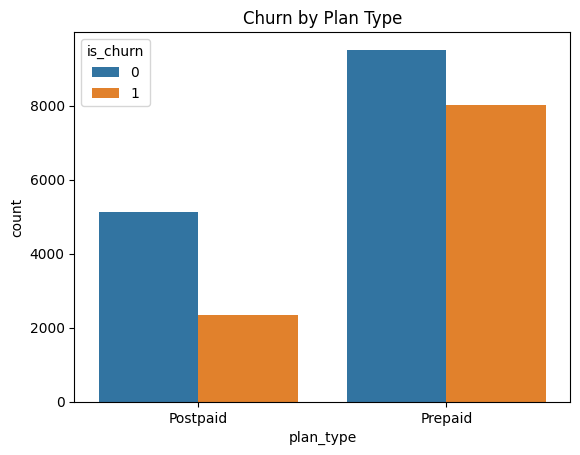

In [12]:
sns.countplot(x="plan_type", hue="is_churn", data=df)
plt.title("Churn by Plan Type")
plt.show()

We can establish whether certain plans have higher levels of association with customer churn by examining the churn rate for different plans.

Telecom companies can improve certain plans to lower the rate of customer churn by knowing the differences.

In [13]:
pd.crosstab(df["gender"],df["is_churn"],normalize="index")*100

is_churn,0,1
gender,,
Female,58.624689,41.375311
Male,58.249581,41.750419
Other,61.818182,38.181818


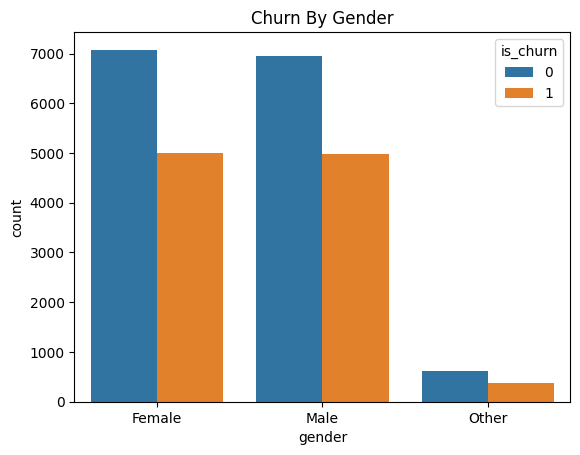

In [14]:
sns.countplot(x="gender", hue="is_churn",data=df)
plt.title("Churn By Gender")
plt.show()

Gender-based analysis helps determine whether churn behavior differs between male and female customers.

In [15]:

df['tenure_bucket'] = pd.cut(df['tenure_months'], bins=[0,12,36,60,100], labels=['0-12','13-36','37-60','60+'])

In [16]:
pd.crosstab(df['tenure_bucket'], df['is_churn'], normalize='index') * 100

is_churn,0,1
tenure_bucket,,
0-12,43.979471,56.020529
13-36,56.164659,43.835341
37-60,62.632104,37.367896
60+,61.233168,38.766832


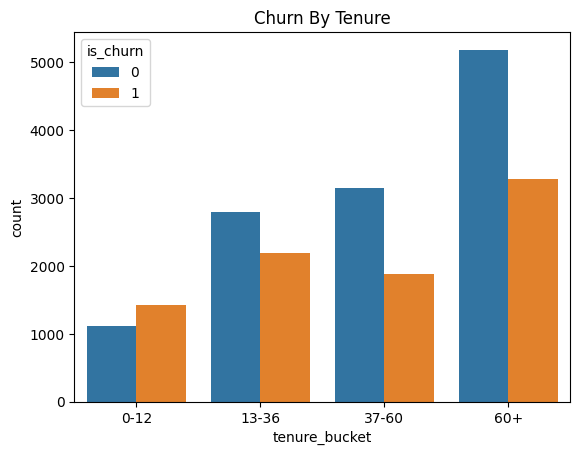

In [17]:
sns.countplot(x="tenure_bucket", hue="is_churn" ,data=df)
plt.title("Churn By Tenure")
plt.show()

Customers with shorter tenure are more likely to churn compared to long-term customers.

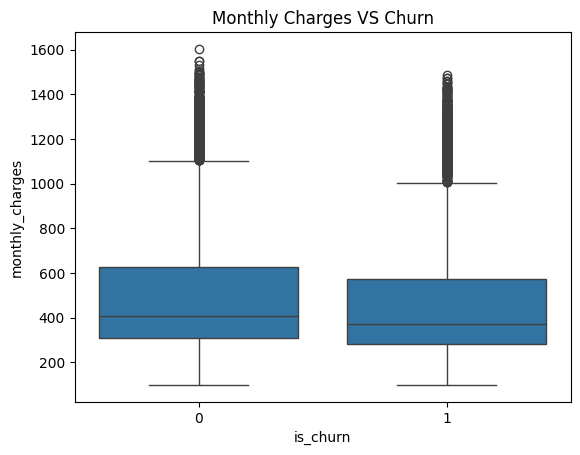

In [18]:
sns.boxplot(x="is_churn", y ="monthly_charges", data=df)
plt.title("Monthly Charges VS Churn")
plt.show()

The boxplot shows a comparison between the monthly charges for the clients who churned and those who remained active.

Pricing might influence customer retention if the amount charged to the customers who churned is higher than that charged to the active customers.

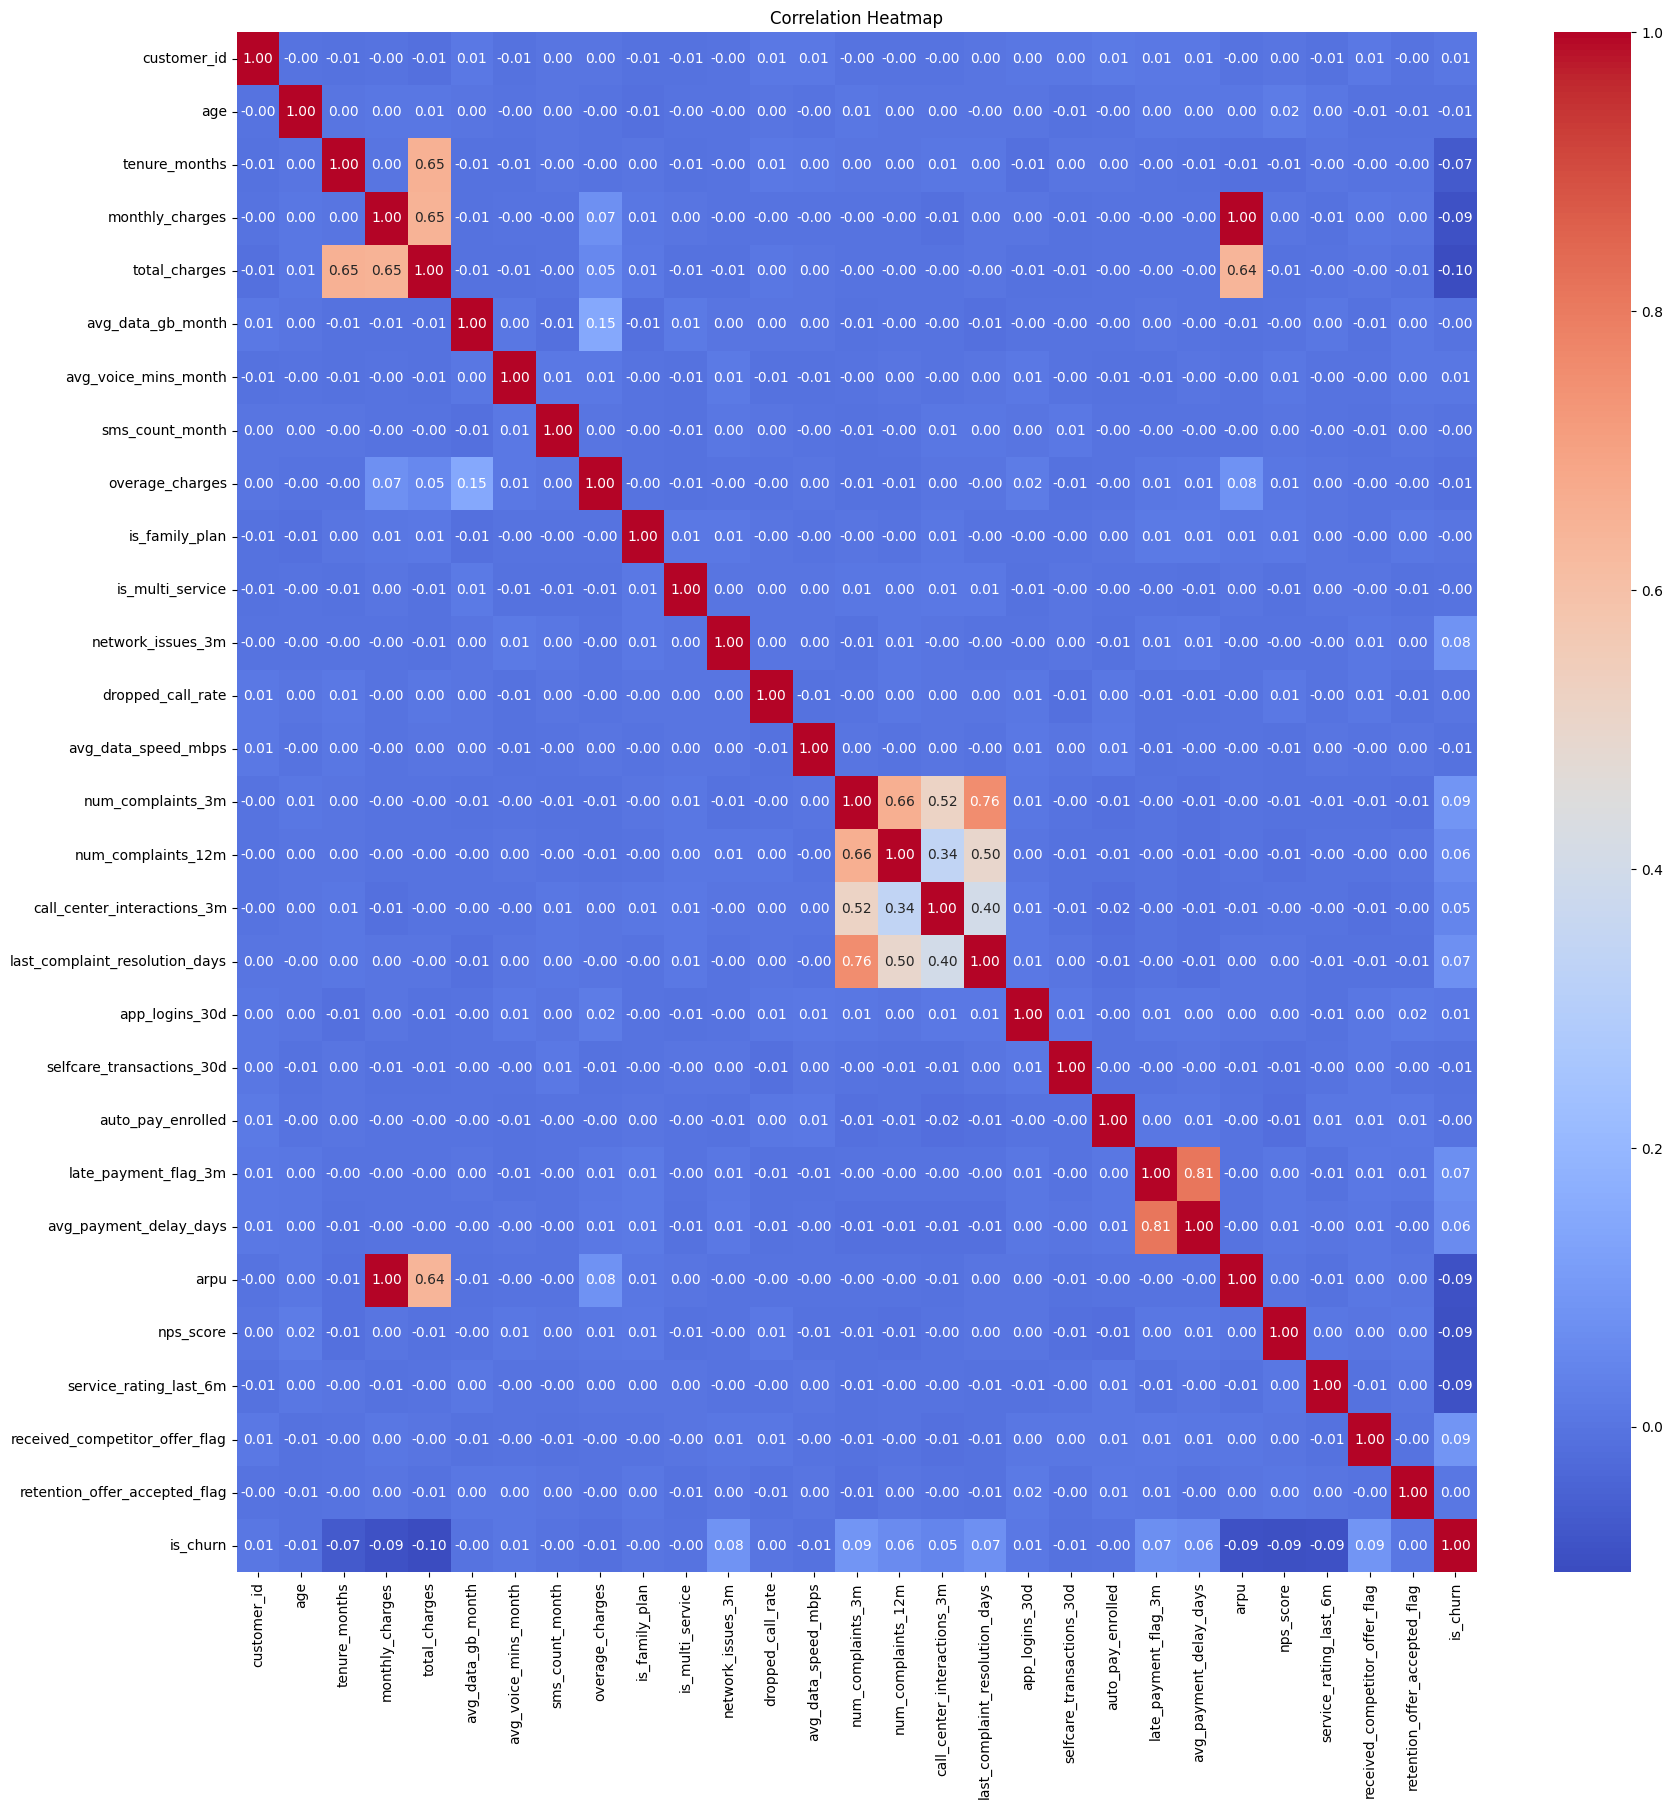

In [19]:
plt.figure(figsize=(20,20))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt =".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Correlation analysis helps identify relationships between numerical variables in the dataset.

## Phase 2 Summary
In this stage, EDA was performed, which helped to better analyze the behavior of consumers, identifying tendencies of customer churn.

Some of the key findings of the analysis include:

• The data comprises a significant percentage of customer churn data.  
• Some plans tend to have higher rates of customer churn.  
• Customers who have been associated with the company for a lesser period of time tend to have higher rates of customer churn.  
• The monthly fees might influence customer churn.

These findings provide valuable insights for feature selection and modeling.

In the next stage, based on the patterns obtained during the exploratory research, machine learning models will be developed for predicting customer attrition.

## Phase 3: Feature Engineering

In this phase, new and significant features are created.

In this phase, new features are created based on complaints from the client, tenure, billing, and payment delays. The objective of creating these artificial features is to identify potential churn possibilities that might not be captured in the existing data set.

In [20]:
df["bill_shock_flag"] = (df["monthly_charges"]>df["monthly_charges"].mean() + df["monthly_charges"].std()).astype(int)

In [21]:
df["payment_risk"] = (df["avg_payment_delay_days"]>10).astype(int)

In [22]:
df["high_complaint_flag"] = (df["num_complaints_12m"]>2).astype(int)

In [23]:
df["arpu_bucket"] = pd.qcut(df["monthly_charges"], q =3, labels =["Low","Medium","High"])

## Phase 3 Summary

In this phase, several new features were created.

Bill shock indicators, payment risk, complaint risk, and ARPU bucket are some of the new features created in this phase.

Machine learning model performance can be improved by employing feature engineering, where raw telecom data is transformed into a more useful format.

In the next phase, the improved data will be used in the creation of a model that can identify the likelihood of a client leaving.

# Phase 4: Data Preparation and Feature Encoding

Before the actual training of the machine learning model can take place, the data needs to be prepared in a form that can be fed into the model.

Machine learning models can only work with numerical data, which means that the categorical variables in the data set need to be converted into numerical form.

The following steps are performed in the fourth phase:

• Categorical variables identification  
• Encoding the categorical variables using one-hot encoding  
• Preparation of the feature matrix and target variable  
• Splitting the data into the training set and test set  
• Applying SMOTE to the classes  
• Standard scaling was also performed to prepare the data for models that require normalization, such as Logistic Regression.

In [24]:
x = df.drop("is_churn", axis =1)
y = df["is_churn"]

In [25]:
categorical_cols = x.select_dtypes(include=["object","category"]).columns
categorical_cols

Index(['gender', 'region_circle', 'connection_type', 'plan_type',
       'contract_type', 'base_plan_category', 'segment_value', 'tenure_bucket',
       'arpu_bucket'],
      dtype='object')

In [26]:
x = pd.get_dummies(x, columns=categorical_cols, drop_first=True)

In [27]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42, stratify = y)

In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [29]:
y_train.value_counts()
y_train_smote.value_counts()

is_churn
1    10250
0    10250
Name: count, dtype: int64

Although the imbalance is moderate, improving recall for churn customers is business-critical. Therefore, SMOTE was applied to enhance minority class learning.

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train_smote)
X_test_scaled = scaler.transform(x_test)

## Phase 4 Summary

In the fourth phase, the dataset was prepared for machine learning modeling.

The categorical variables in the dataset were converted into numerical form by using one-hot encoding. The dataset was split into the training set and the test set to test the performance of the model.

With the data in the correct form, the next phase is to develop classification models to predict customer churn.

## Phase 5: Machine Learning Model Development

The objective of this phase is to develop machine learning models that have the ability to predict client attrition.

The process involved in modeling consists of encoding categorical data, splitting data into training and testing datasets, developing classification models, and evaluating the models.

The developed model would be useful to telecommunication firms in proactively identifying clients at risk of attrition and taking necessary measures to retain clients.

In [31]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter = 1000)
log_model.fit(X_train_scaled,y_train_smote)
y_pred_log = log_model.predict(X_test_scaled)

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
rf_model.fit(x_train_smote,y_train_smote)
y_prob = rf_model.predict_proba(x_test)[:,1]

y_pred_rf = (y_prob > 0.4).astype(int)

In [33]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()
gb_model.fit(x_train_smote,y_train_smote)
y_pred_gb = gb_model.predict(x_test)

In [34]:
from sklearn.metrics import classification_report

print("Logistic Regression classification Report")
print(classification_report(y_test, y_pred_log))

Logistic Regression classification Report
              precision    recall  f1-score   support

           0       0.66      0.71      0.68      4393
           1       0.54      0.48      0.51      3107

    accuracy                           0.61      7500
   macro avg       0.60      0.59      0.60      7500
weighted avg       0.61      0.61      0.61      7500



In [35]:
print("Random Forest classification Report")
print(classification_report(y_test, y_pred_rf))

Random Forest classification Report
              precision    recall  f1-score   support

           0       0.72      0.35      0.47      4393
           1       0.47      0.81      0.59      3107

    accuracy                           0.54      7500
   macro avg       0.59      0.58      0.53      7500
weighted avg       0.61      0.54      0.52      7500



In [36]:
print("Gradient Boosting classification Report")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting classification Report
              precision    recall  f1-score   support

           0       0.66      0.74      0.70      4393
           1       0.55      0.45      0.50      3107

    accuracy                           0.62      7500
   macro avg       0.61      0.60      0.60      7500
weighted avg       0.61      0.62      0.61      7500



### Model Selection

Since the main objective of the churn prediction is to identify the customers who are likely to leave the service, recall is a key evaluation criterion. The higher the recall, the higher the number of customers that are likely to be identified as churn, and hence the business can take measures to retain them. Therefore, the Random Forest model is selected for deployment.

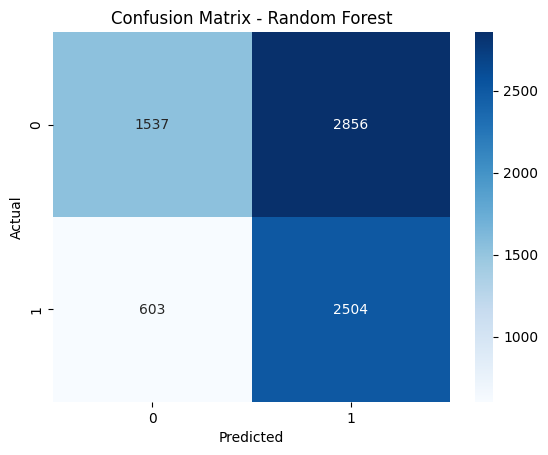

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

c:\Users\abhin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Random Forest AUC score: 0.5785951345628352


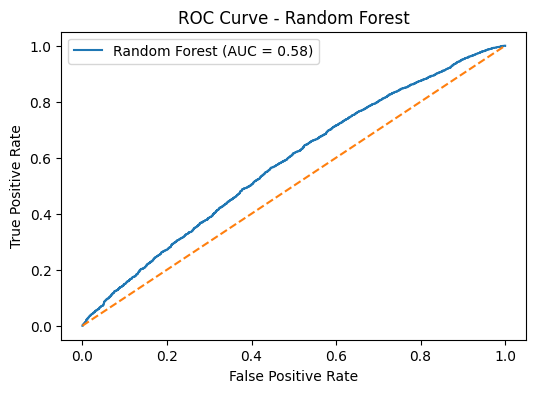

In [38]:
from sklearn.metrics import roc_curve, auc

# Probability predictions
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

roc_auc = auc(fpr, tpr)
print("Random Forest AUC score:", roc_auc)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

The ROC curve measures how well the model performs in discriminating between churners and non-churners.
The higher the value of the Area Under Curve (AUC), the better the performance of the model in discriminating between two classes.
The ROC-AUC metric in churn prediction problems measures how well the model ranks the customers in terms of probability.

In [39]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

feature_importance.head(10)

last_complaint_resolution_days    0.062227
nps_score                         0.061843
service_rating_last_6m            0.049665
total_charges                     0.047073
plan_type_Prepaid                 0.044886
contract_type_No Contract         0.042703
monthly_charges                   0.042105
arpu                              0.041593
tenure_months                     0.040755
avg_payment_delay_days            0.036230
dtype: float64

This is demonstrated by the feature importance analysis, which indicates the variables that impact the model's predictions 
most. Features such as tenure, monthly charges, complaints made, and payment delays appear to impact predictions 
most. This can be used by telecommunication companies to identify customers who are at a higher risk of churning.

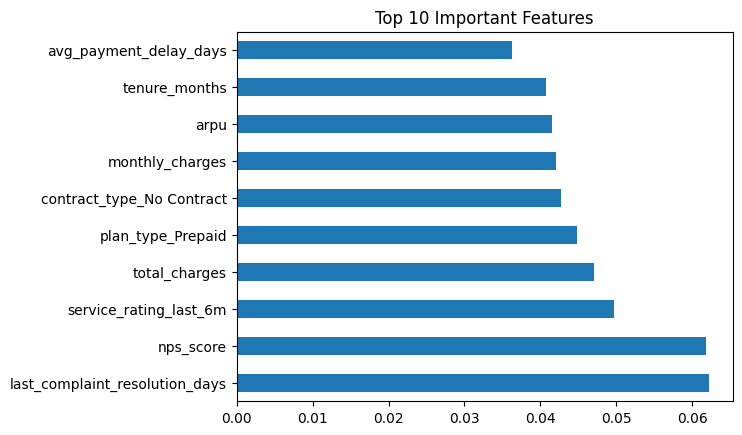

In [40]:
feature_importance.head(10).plot(kind="barh")

plt.title("Top 10 Important Features")
plt.show()

## Phase 5 Summary
At this phase, a model for predicting customer attrition has been made.

Encoding of categorical variables and division of data into training and testing data were performed. A logistic regression classifier has been used as a baseline model to identify trends related to churn.

Model performance has been measured by precision, recall, and F1-score. Further information on classification accuracy has been provided by the confusion matrix.

Results obtained by this model are used for further model improvements and business intelligence.

## Phase 6: Model Explainability using SHAP

Machine learning models can be highly accurate in their predictions, and it is equally important to understand how these predictions are made. Explainability of models is an essential aspect.

In this phase, SHAP values will be used to understand the decisions made by the model. SHAP stands for SHapley Additive exPlanations. SHAP values can be used to understand how each feature contributes to the final prediction.

This will enable better transparency and enable business decisions to be made on the results obtained.

In [41]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(x_test)

c:\Users\abhin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [42]:
print(type(shap_values))
print(len(shap_values))

<class 'numpy.ndarray'>
7500


In [43]:
print(shap_values.shape)

(7500, 55, 2)


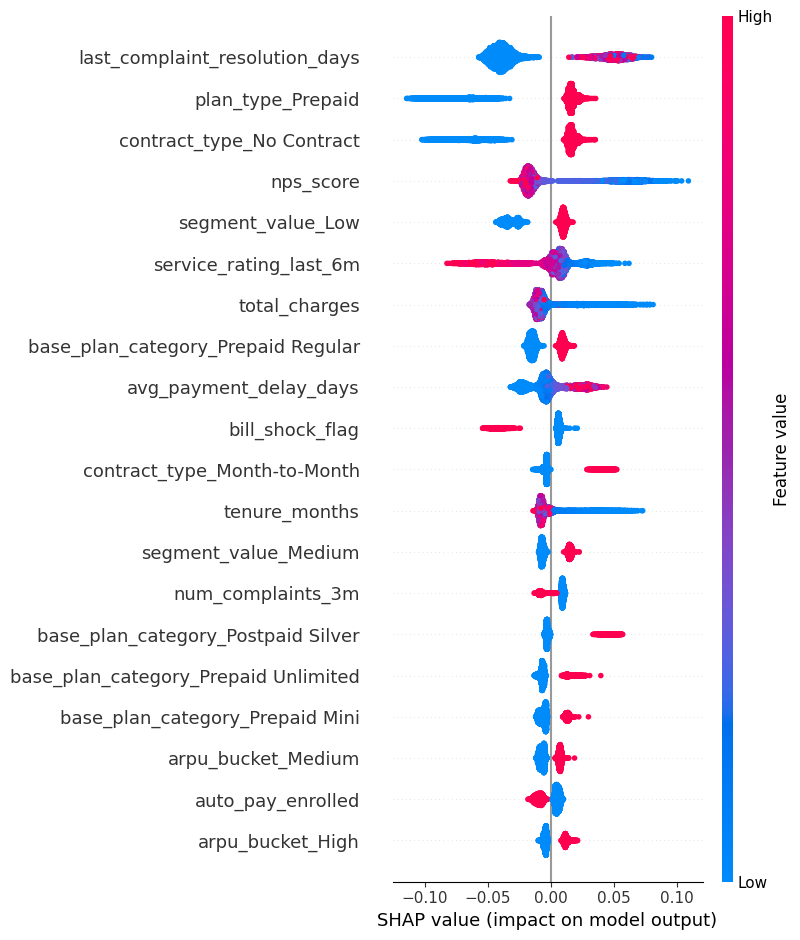

In [44]:
shap.summary_plot(shap_values[:,:,1], x_test)

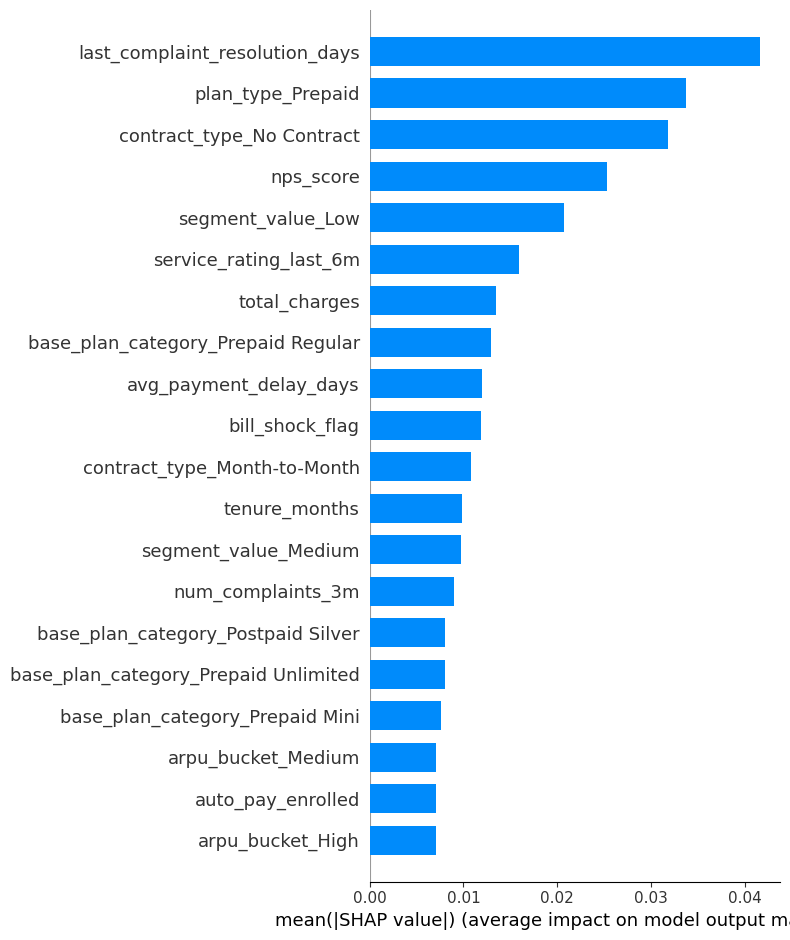

In [45]:
shap.summary_plot(shap_values[:,:,1], x_test, plot_type="bar")

## Phase 6 Summary

In the SHAP interpretation, the important factors that affect the model in predicting churn are identified. The higher the value in the SHAP analysis, the higher the impact on the prediction.

In this analysis, we can see that factors such as tenure, monthly charge, and complaint frequency are the important factors that affect the prediction model.

In the case of a telecom company, if a customer has a lower tenure and higher monthly charge, there is a higher probability that the customer might churn.

## Phase 7: Business Insights and Recommendations

The results obtained from the machine learning models and feature importance analysis reveal several meaningful patterns related to customer churn.

Customers with shorter tenure demonstrate a significantly higher probability of leaving the telecom service. This indicates that the **initial months of the customer lifecycle are the most critical period for retention**, and early engagement strategies are essential.

Customers with higher monthly charges also show an increased likelihood of churn. This suggests that certain customers may be **price sensitive**, and pricing structures or value perception may influence their decision to stay or leave.

Payment behavior also plays a major role. Customers who frequently delay their payments show a higher probability of churn. This may indicate **financial friction, dissatisfaction with services, or weakening customer engagement**.

Customer complaints are another strong indicator of churn risk. A higher number of complaints often reflects **poor service experience**, which increases the likelihood that customers will switch to competitors.

Service ratings also contribute significantly to churn prediction. Customers with lower service ratings tend to churn more frequently, indicating the importance of maintaining high service quality and customer satisfaction.

### Business Recommendations

Based on the insights derived from the analysis, several strategic recommendations can be proposed.

Telecom companies should focus on **retention strategies during the first year of service**, such as onboarding programs, welcome offers, and proactive customer engagement initiatives.

High-value customers who pay higher monthly charges should be targeted with **personalized offers, loyalty programs, and bundled services** to improve perceived value and reduce churn risk.

Payment delay patterns can be used as an **early warning signal** to identify customers who may require proactive support or flexible billing options.

Improving the **speed and quality of complaint resolution** can significantly enhance customer satisfaction and reduce churn probability.

Finally, telecom companies can integrate predictive models like this one into their customer management systems to **continuously monitor churn risk and trigger automated retention actions**.


In [46]:
import pickle
import os

model_data = {
    "model": rf_model,
    "features": x.columns
}


model_path = os.path.join("..", "app", "churn_model.pkl")
pickle.dump(model_data, open(model_path, "wb"))

In [47]:
df.to_csv("telecom_churn_cleaned.csv", index=False)